# 1. Context

# 2. Environment Setup

In [1]:
# ====================================================================
# Cell 2: Library Imports, Environment Setup, and Dependency Verification
# ====================================================================

import os
import sys
import json
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Suppress minor warnings for clean academic presentation
warnings.filterwarnings('ignore')

# Computer Vision and Image Processing Libraries
import cv2
from skimage.feature import local_binary_pattern, hog
from skimage import io, color

# Machine Learning and Dimensionality Reduction
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Print software dependency versions to verify environment reproducibility
print("=========================================")
print("  DEPENDENCY DIAGNOSTIC CHECK")
print("=========================================")
print(f"Python Version      : {sys.version.split()[0]}")
print(f"OpenCV (cv2)        : {cv2.__version__}")
print(f"NumPy Version       : {np.__version__}")
print(f"Pandas Version      : {pd.__version__}")
print(f"XGBoost Version     : {xgb.__version__}")
print("=========================================")
print("System setup is complete. All libraries imported successfully.")

  DEPENDENCY DIAGNOSTIC CHECK
Python Version      : 3.12.3
OpenCV (cv2)        : 4.13.0
NumPy Version       : 1.26.4
Pandas Version      : 2.2.2
XGBoost Version     : 2.0.3
System setup is complete. All libraries imported successfully.


# 3. Dataset Loading & Class Mapping

- **Programmatic Outlier Filtering and Domain Realignment:** *To ensure high generalization and prevent shortcut learning (domain bias), a programmatic outlier filtering layer is implemented during dataset loading. The raw dataset contains annotated bounding boxes for metallic debris and soda cans (Class 4). Because these metallic objects do not align with the strict target domain of cardboard boxes and introduce strong visual artifacts (such as highly reflective surfaces and cylindrical structures) that models can exploit as non-cardboard shortcuts, any image containing Class 4 annotations is programmatically discarded. This realignment guarantees that the classifier strictly learns the localized geometric and textural anomalies of cardboard materials.*

In [2]:
# ====================================================================
# Cell 3: Robust Raw Dataset Loader and Class Mapping Parser
# ====================================================================

def load_and_pool_raw_dataset(dataset_root, target_size=(128, 128)):
    """
    Traverses the train, valid, and test subdirectories of the YOLO dataset,
    parses annotation class IDs, applies binary mapping, and pools all
    raw grayscale images and labels into unified numpy arrays.
    
    To maintain strict domain alignment (cardboard boxes only) and prevent 
    shortcut learning from irrelevant objects, images containing class ID 4 (metal/cans) 
    are programmatically skipped.
    
    Active Defect Classes (Damaged - 1): 1 (Defect), 2 (cut), 3 (deform), 6 (open)
    Excluded Classes (Skipped)         : 4 (metal - out-of-domain cans/debris)
    Non-Defect Classes (Intact - 0)    : 0 (Cardboard Box wrapper), 5 (no defect)
    """
    splits = ["train", "valid", "test"]
    supported_extensions = (".jpg", ".jpeg", ".png", ".bmp")
    active_defect_classes = {1, 2, 3, 6}
    excluded_class = 4
    
    pooled_images = []
    pooled_labels = []
    skipped_count = 0
    
    # Verify dataset root directory exists
    if not os.path.exists(dataset_root):
        raise FileNotFoundError(f"Target dataset root directory not found: {dataset_root}")
        
    for split in splits:
        images_dir = os.path.join(dataset_root, split, "images")
        labels_dir = os.path.join(dataset_root, split, "labels")
        
        if not os.path.exists(images_dir):
            print(f"[Warning] Directory not found, skipping split: {images_dir}")
            continue
            
        image_files = [
            f for f in os.listdir(images_dir) 
            if f.lower().endswith(supported_extensions)
        ]
        
        for img_filename in image_files:
            img_path = os.path.join(images_dir, img_filename)
            base_name = os.path.splitext(img_filename)[0]
            label_filename = f"{base_name}.txt"
            label_path = os.path.join(labels_dir, label_filename)
            
            # First, parse annotations to check for out-of-domain Class 4 (metal/cans)
            contains_out_of_domain = False
            is_damaged = False
            
            if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
                with open(label_path, 'r') as f:
                    for line in f:
                        parts = line.strip().split()
                        if parts:
                            class_id = int(parts[0])
                            if class_id == excluded_class:
                                contains_out_of_domain = True
                                break
                            elif class_id in active_defect_classes:
                                is_damaged = True
            
            # Skip the entire sample if it contains non-box metal objects (e.g., soda cans)
            if contains_out_of_domain:
                skipped_count += 1
                continue
                
            # Read image in grayscale format and resize to normalized target size
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
                
            img_resized = cv2.resize(img, target_size)
            label = 1 if is_damaged else 0
            pooled_images.append(img_resized)
            pooled_labels.append(label)
            
    print(f"[Domain Alignment] Skipped {skipped_count} images containing Class {excluded_class} (metal/cans) to protect the model from shortcut learning.")
    return np.array(pooled_images), np.array(pooled_labels)


# Define dataset absolute root directory matching the user workspace
DATASET_ROOT = "/home/canozkan/thesis_ws/src/cardbox_dataset"

try:
    print("Loading and pooling raw dataset from all splits with strict domain alignment...")
    X_raw, y_raw = load_and_pool_raw_dataset(DATASET_ROOT)
    
    intact_count = np.sum(y_raw == 0)
    damaged_count = np.sum(y_raw == 1)
    
    print("\n=========================================")
    print("  RAW DATASET POOLING COMPLETED")
    print("=========================================")
    print(f"Total Unified Images : {X_raw.shape[0]}")
    print(f"Total Intact Boxes   : {intact_count} ({intact_count/X_raw.shape[0]*100:.2f}%)")
    print(f"Total Damaged Boxes  : {damaged_count} ({damaged_count/X_raw.shape[0]*100:.2f}%)")
    print("=========================================")
    
except Exception as e:
    print(f"[Error] Failed during raw dataset processing: {e}")

Loading and pooling raw dataset from all splits with strict domain alignment...
[Domain Alignment] Skipped 65 images containing Class 4 (metal/cans) to protect the model from shortcut learning.

  RAW DATASET POOLING COMPLETED
Total Unified Images : 210
Total Intact Boxes   : 77 (36.67%)
Total Damaged Boxes  : 133 (63.33%)


# 4. Stratified Splitting

In [3]:
# ====================================================================
# Cell 4: Leakage-Free Stratified Train/Test Partitioning
# ====================================================================

# Perform an 80/20 stratified split to isolate raw validation data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, 
    y_raw, 
    test_size=0.20, 
    stratify=y_raw, 
    random_state=42
)

# Calculate distribution metrics for training partition
train_total = X_train_raw.shape[0]
train_intact = np.sum(y_train == 0)
train_damaged = np.sum(y_train == 1)

# Calculate distribution metrics for test partition
test_total = X_test_raw.shape[0]
test_intact = np.sum(y_test == 0)
test_damaged = np.sum(y_test == 1)

print("=========================================")
print("  STRATIFIED PARTITIONING COMPLETED")
print("=========================================")
print(f"Unified Raw Training Set ({train_total} images):")
print(f"  * Intact (Class 0)  : {train_intact} ({train_intact/train_total*100:.2f}%)")
print(f"  * Damaged (Class 1) : {train_damaged} ({train_damaged/train_total*100:.2f}%)")
print(f"\nIsolated Raw Test Set ({test_total} images):")
print(f"  * Intact (Class 0)  : {test_intact} ({test_intact/test_total*100:.2f}%)")
print(f"  * Damaged (Class 1) : {test_damaged} ({test_damaged/test_total*100:.2f}%)")
print("=========================================")
print("Methodological isolation verified. Test set is strictly locked away.")

  STRATIFIED PARTITIONING COMPLETED
Unified Raw Training Set (168 images):
  * Intact (Class 0)  : 62 (36.90%)
  * Damaged (Class 1) : 106 (63.10%)

Isolated Raw Test Set (42 images):
  * Intact (Class 0)  : 15 (35.71%)
  * Damaged (Class 1) : 27 (64.29%)
Methodological isolation verified. Test set is strictly locked away.


# 5. Exploratory Data Analysis

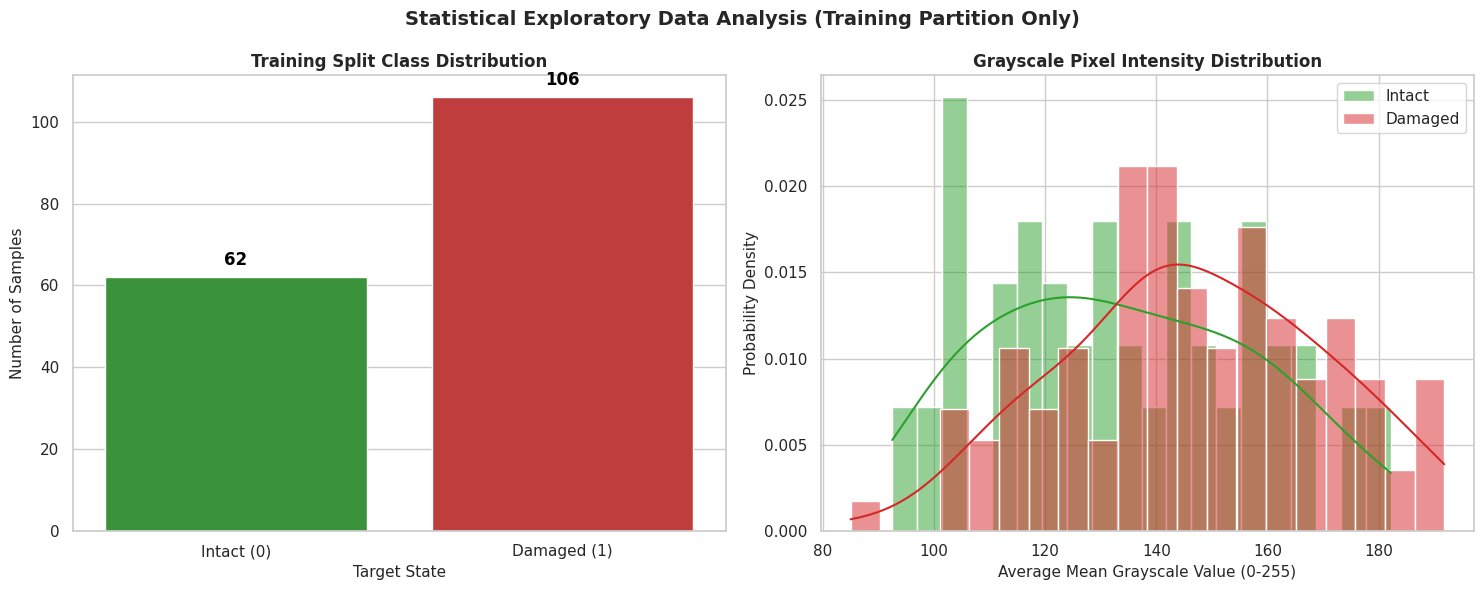

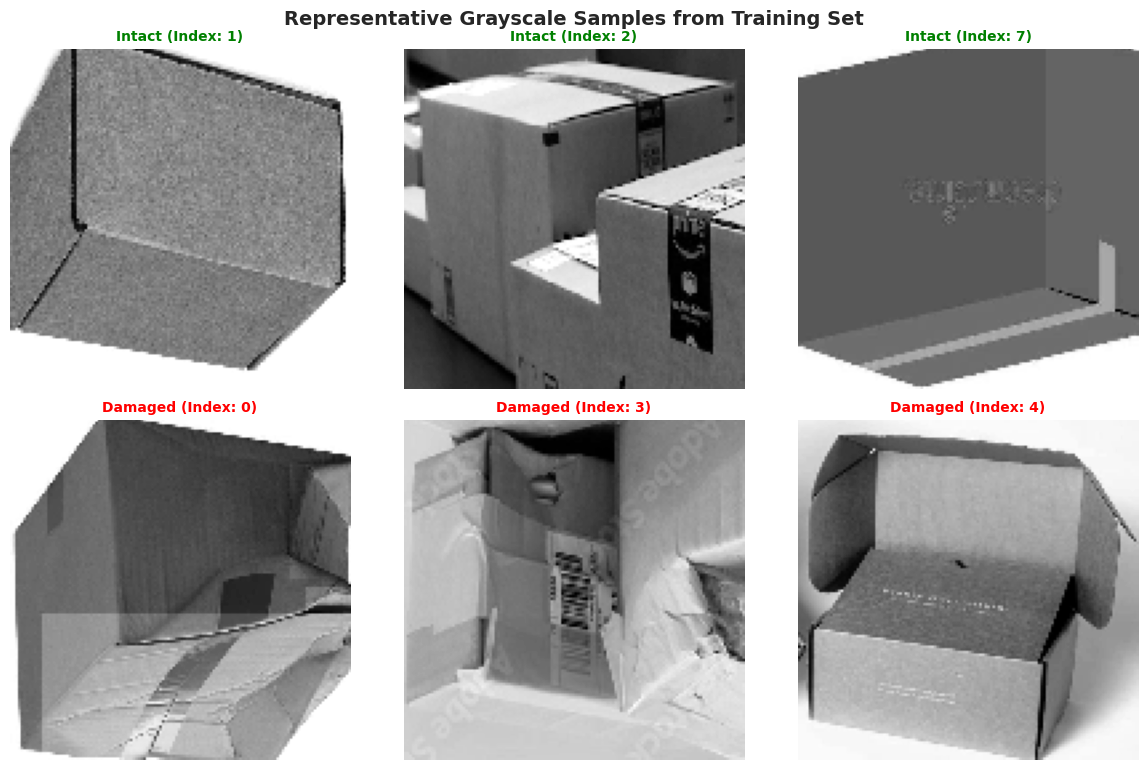

  EXPLORATORY DATA ANALYSIS COMPLETED
Academic insights derived from distributions.


In [4]:
# ====================================================================
# Cell 5: Academic-Grade Exploratory Data Analysis (EDA) on Training Set
# ====================================================================

# Set clean whitegrid theme for academic publishing standards
sns.set_theme(style="whitegrid")

# Create Figure 1: Statistical EDA (Class Distribution and Brightness Analysis)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Class Distribution Analysis
df_dist = pd.DataFrame({
    'Class': ['Intact (0)', 'Damaged (1)'], 
    'Count': [train_intact, train_damaged]
})
sns.barplot(x='Class', y='Count', data=df_dist, ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_title("Training Split Class Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Target State", fontsize=11)
axes[0].set_ylabel("Number of Samples", fontsize=11)

# Annotate values on top of the bars
for index, row in df_dist.iterrows():
    axes[0].text(index, row['Count'] + 3, str(row['Count']), color='black', ha="center", fontweight='bold')

# Plot 2: Average Grayscale Pixel Intensity Analysis
# Calculate mean intensity of each grayscale image to prove simple thresholding is insufficient
mean_intensities = np.mean(X_train_raw, axis=(1, 2))
intact_means = mean_intensities[y_train == 0]
damaged_means = mean_intensities[y_train == 1]

sns.histplot(intact_means, ax=axes[1], color='#2ca02c', label='Intact', kde=True, bins=20, alpha=0.5, stat="density")
sns.histplot(damaged_means, ax=axes[1], color='#d62728', label='Damaged', kde=True, bins=20, alpha=0.5, stat="density")
axes[1].set_title("Grayscale Pixel Intensity Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Average Mean Grayscale Value (0-255)", fontsize=11)
axes[1].set_ylabel("Probability Density", fontsize=11)
axes[1].legend(loc="upper right")

plt.suptitle("Statistical Exploratory Data Analysis (Training Partition Only)", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# Create Figure 2: Visual EDA (Raw Sample Representation Grid)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Extract indices for representative mapping
intact_indices = np.where(y_train == 0)[0][:3]
damaged_indices = np.where(y_train == 1)[0][:3]

# Plot top row: Intact Cardboard Boxes
for col_idx, img_idx in enumerate(intact_indices):
    axes[0, col_idx].imshow(X_train_raw[img_idx], cmap='gray')
    axes[0, col_idx].set_title(f"Intact (Index: {img_idx})", color='green', fontsize=10, fontweight='bold')
    axes[0, col_idx].axis('off')

# Plot bottom row: Damaged Cardboard Boxes
for col_idx, img_idx in enumerate(damaged_indices):
    axes[1, col_idx].imshow(X_train_raw[img_idx], cmap='gray')
    axes[1, col_idx].set_title(f"Damaged (Index: {img_idx})", color='red', fontsize=10, fontweight='bold')
    axes[1, col_idx].axis('off')

plt.suptitle("Representative Grayscale Samples from Training Set", fontsize=14, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()

print("=========================================")
print("  EXPLORATORY DATA ANALYSIS COMPLETED")
print("=========================================")
print("Academic insights derived from distributions.")

# 6. Class-Balanced Data Augmentation for the Training Set

  CLASS-BALANCED AUGMENTATION REPORT
Original Training Dataset Size : 168 images
Augmented Training Dataset Size: 460 images
  * Intact (Class 0)           : 248 (53.91%)
  * Damaged (Class 1)          : 212 (46.09%)


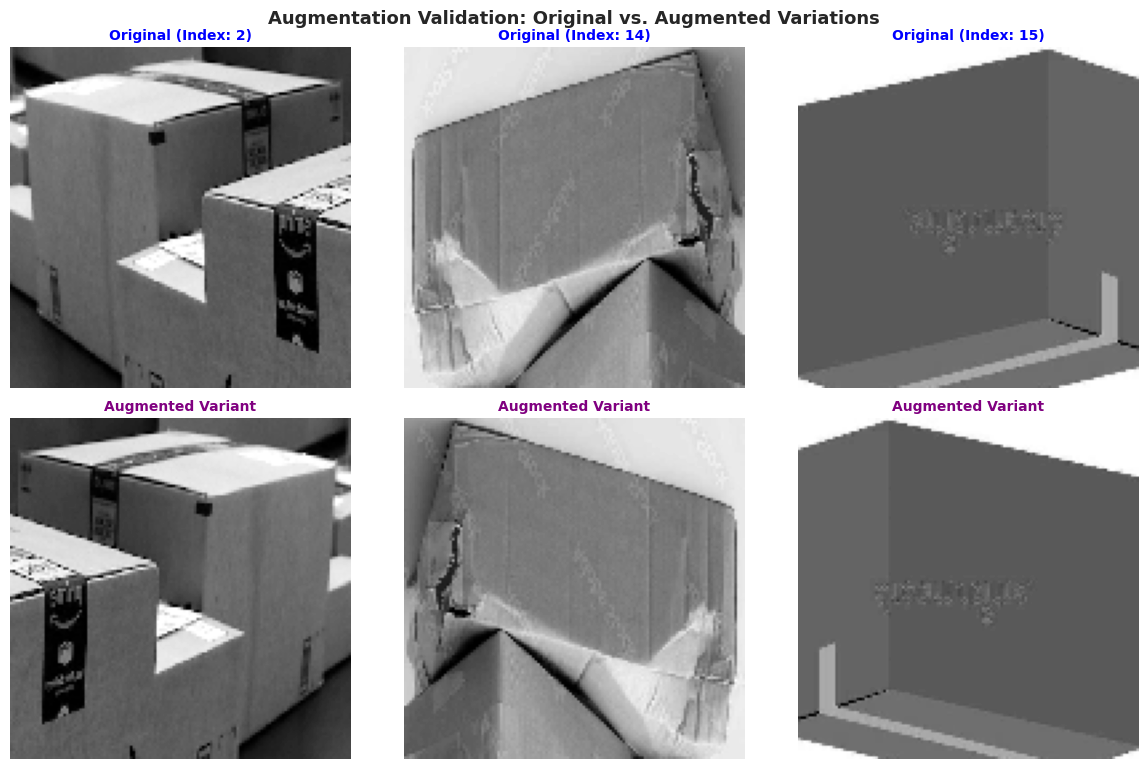

In [5]:
# ====================================================================
# Cell 6: Reproducible Class-Balanced Data Augmentation for Train Set
# ====================================================================

# Set seed for exact reproducibility of augmented synthetic variations
np.random.seed(42)

def generate_augmented_variants(image, count):
    """
    Generates realistic robotic defect-safe variations of a grayscale image.
    Count defines how many dynamic augmented versions to generate.
    """
    variants = []
    h, w = image.shape
    
    for _ in range(count):
        # Randomly choose an augmentation operation
        aug_type = np.random.choice(['rotate', 'flip', 'brightness'])
        
        if aug_type == 'rotate':
            # Slight rotation simulating robotic camera alignment variations
            angle = np.random.uniform(-10, 10)
            M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
            augmented = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REFLECT)
            
        elif aug_type == 'flip':
            # Horizontal flip simulating opposite corridor viewpoints
            augmented = cv2.flip(image, 1)
            
        else:
            # Radiometric brightness scaling simulating warehouse lighting fluctuations
            scale_factor = np.random.uniform(0.85, 1.15)
            augmented = np.clip(image * scale_factor, 0, 255).astype(np.uint8)
            
        variants.append(augmented)
        
    return variants

# Separate current training samples to perform target-balanced oversampling
X_train_intact = X_train_raw[y_train == 0]
X_train_damaged = X_train_raw[y_train == 1]

X_augmented_list = []
y_augmented_list = []

# 1. Process Intact Class (Minority): Generate original + 3 augmented variants (4x total)
for img in X_train_intact:
    # Append original image
    X_augmented_list.append(img)
    y_augmented_list.append(0)
    # Generate and append 3 synthetic variants
    variants = generate_augmented_variants(img, count=3)
    for var in variants:
        X_augmented_list.append(var)
        y_augmented_list.append(0)

# 2. Process Damaged Class (Majority): Generate original + 1 augmented variant (2x total)
for img in X_train_damaged:
    # Append original image
    X_augmented_list.append(img)
    y_augmented_list.append(1)
    # Generate and append 1 synthetic variant
    variants = generate_augmented_variants(img, count=1)
    for var in variants:
        X_augmented_list.append(var)
        y_augmented_list.append(1)

# Convert outputs to unified numpy structures
X_train_aug = np.array(X_augmented_list)
y_train_aug = np.array(y_augmented_list)

# Verify new dataset balance shapes
total_aug = X_train_aug.shape[0]
aug_intact = np.sum(y_train_aug == 0)
aug_damaged = np.sum(y_train_aug == 1)

print("=========================================")
print("  CLASS-BALANCED AUGMENTATION REPORT")
print("=========================================")
print(f"Original Training Dataset Size : {X_train_raw.shape[0]} images")
print(f"Augmented Training Dataset Size: {total_aug} images")
print(f"  * Intact (Class 0)           : {aug_intact} ({aug_intact/total_aug*100:.2f}%)")
print(f"  * Damaged (Class 1)          : {aug_damaged} ({aug_damaged/total_aug*100:.2f}%)")
print("=========================================")

# Visual Validation Plot: Show Original vs. Augmented Pairs
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
sample_indices = [2, 14, 15] # Select same samples used in EDA for visual comparison

for i, idx in enumerate(sample_indices):
    # Find position of original image in augmented dataset
    original_idx = np.where((X_train_aug == X_train_raw[idx]).all(axis=(1,2)))[0][0]
    
    # Original image plot
    axes[0, i].imshow(X_train_raw[idx], cmap='gray')
    axes[0, i].set_title(f"Original (Index: {idx})", color='blue', fontsize=10, fontweight='bold')
    axes[0, i].axis('off')
    
    # Visualizing corresponding augmented variant (next element in list)
    axes[1, i].imshow(X_train_aug[original_idx + 1], cmap='gray')
    axes[1, i].set_title("Augmented Variant", color='purple', fontsize=10, fontweight='bold')
    axes[1, i].axis('off')

plt.suptitle("Augmentation Validation: Original vs. Augmented Variations", fontsize=13, fontweight='bold', y=0.96)
plt.tight_layout()
plt.show()

# 7. Micro-Texture and Macro-Structural Feature Extraction

In [6]:
# ====================================================================
# Cell 7: Feature Extraction Pipeline (Spatial-LBP + HOG)
# ====================================================================

def extract_spatial_lbp(image, P=8, R=1, grid_rows=4, grid_cols=4):
    """
    Computes Local Binary Patterns (LBP) using the uniform method, 
    divides the LBP mapping into a grid of blocks, and extracts 
    concatenated normalized histograms.
    """
    lbp = local_binary_pattern(image, P, R, method='uniform')
    h, w = image.shape
    block_h = h // grid_rows
    block_w = w // grid_cols
    spatial_features = []
    
    for i in range(grid_rows):
        for j in range(grid_cols):
            block = lbp[i*block_h : (i+1)*block_h, j*block_w : (j+1)*block_w]
            hist, _ = np.histogram(
                block.ravel(), 
                bins=np.arange(0, P + 3), 
                range=(0, P + 2), 
                density=True
            )
            spatial_features.extend(hist)
            
    return np.array(spatial_features)

def extract_hog_features(image):
    """
    Extracts Histogram of Oriented Gradients (HOG) from grayscale image.
    Using standardized parameters optimized for cardboard structural deformities.
    """
    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    return features

# 1. Feature Extraction on Augmented Training Set
print("Extracting features from Augmented Training Set...")
t0 = time.time()
X_train_lbp = np.array([extract_spatial_lbp(img) for img in X_train_aug])
X_train_hog = np.array([extract_hog_features(img) for img in X_train_aug])
X_train_fused = np.hstack((X_train_lbp, X_train_hog))
t1 = time.time()
print(f"  * Training Set extraction completed in {t1-t0:.2f} seconds.")

# 2. Feature Extraction on Isolated Test Set (Zero Leakage)
print("\nExtracting features from Isolated Test Set...")
t0 = time.time()
X_test_lbp = np.array([extract_spatial_lbp(img) for img in X_test_raw])
X_test_hog = np.array([extract_hog_features(img) for img in X_test_raw])
X_test_fused = np.hstack((X_test_lbp, X_test_hog))
t1 = time.time()
print(f"  * Test Set extraction completed in {t1-t0:.2f} seconds.")

print("\n=========================================")
print("  FEATURE EXTRACTION MATRIX REPORT")
print("=========================================")
print(f"LBP Feature Shape       : 160 features (16 blocks * 10 bins)")
print(f"HOG Feature Shape       : 1764 gradient orientation features")
print(f"Total Fused Dimension   : {X_train_fused.shape[1]} features")
print(f"Training Feature Matrix : {X_train_fused.shape}")
print(f"Test Feature Matrix     : {X_test_fused.shape}")
print("=========================================")

Extracting features from Augmented Training Set...
  * Training Set extraction completed in 1.54 seconds.

Extracting features from Isolated Test Set...
  * Test Set extraction completed in 0.15 seconds.

  FEATURE EXTRACTION MATRIX REPORT
LBP Feature Shape       : 160 features (16 blocks * 10 bins)
HOG Feature Shape       : 1764 gradient orientation features
Total Fused Dimension   : 1924 features
Training Feature Matrix : (460, 1924)
Test Feature Matrix     : (42, 1924)


# 8. Scaling and Dimensionality Reduction via PCA

  STANDARD LEVEL SCALING & PCA REPORT
Original Feature Dimension : 1924 dimensions
Reduced PCA Dimension      : 125 dimensions
Dataset Compression Ratio  : 93.50% reduction
New Training Feature Matrix: (460, 125)
New Test Feature Matrix    : (42, 125)


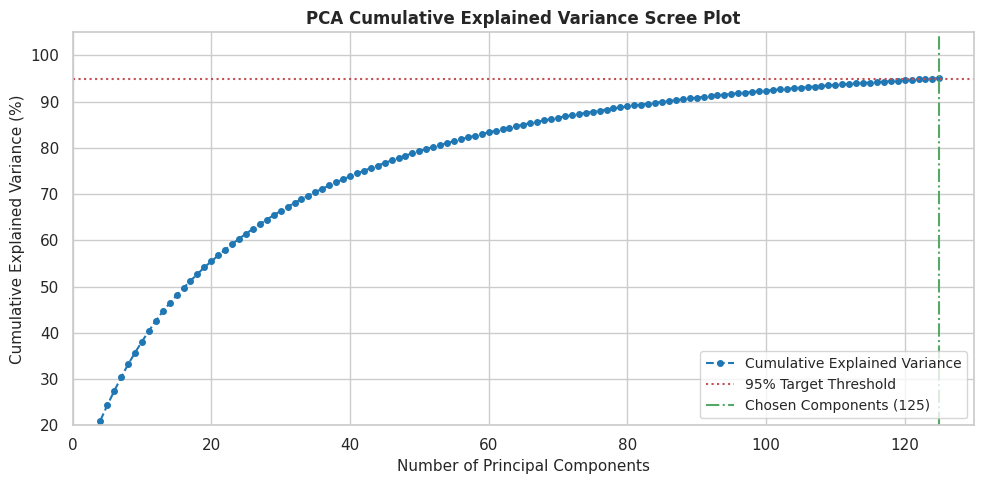

In [7]:
# ====================================================================
# Cell 8: Zero-Leakage Standardization and Explained Variance PCA
# ====================================================================

# 1. Zero-Leakage Standardization
# Initialize scaler and fit strictly on training fused features only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fused)
X_test_scaled = scaler.transform(X_test_fused)

# 2. PCA Dimensionality Reduction
# Retain 95% of total dataset variance using the exact SVD full solver
pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Retrieve dimension counts for reporting
original_dims = X_train_fused.shape[1]
reduced_dims = X_train_pca.shape[1]
compression_ratio = (1 - (reduced_dims / original_dims)) * 100

print("=========================================")
print("  STANDARD LEVEL SCALING & PCA REPORT")
print("=========================================")
print(f"Original Feature Dimension : {original_dims} dimensions")
print(f"Reduced PCA Dimension      : {reduced_dims} dimensions")
print(f"Dataset Compression Ratio  : {compression_ratio:.2f}% reduction")
print(f"New Training Feature Matrix: {X_train_pca.shape}")
print(f"New Test Feature Matrix    : {X_test_pca.shape}")
print("=========================================")

# 3. Academic Visual Verification: Cumulative Explained Variance (Scree Plot)
plt.figure(figsize=(10, 5))
cumulative_variance = np.cumsum(pca.explained_variance_ratio_) * 100

# Plot cumulative explained variance curve
plt.plot(
    range(1, len(cumulative_variance) + 1), 
    cumulative_variance, 
    marker='o', 
    markersize=4,
    linestyle='--', 
    color='#1f77b4', 
    label='Cumulative Explained Variance'
)

# Highlight 95% threshold line
plt.axhline(y=95, color='r', linestyle=':', linewidth=1.5, label='95% Target Threshold')
# Highlight chosen component count
plt.axvline(x=reduced_dims, color='g', linestyle='-.', linewidth=1.5, label=f'Chosen Components ({reduced_dims})')

plt.title("PCA Cumulative Explained Variance Scree Plot", fontsize=12, fontweight='bold')
plt.xlabel("Number of Principal Components", fontsize=11)
plt.ylabel("Cumulative Explained Variance (%)", fontsize=11)
plt.xlim(0, len(cumulative_variance) + 5)
plt.ylim(20, 105)
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

# 9. Model Optimization via Cross-Validation

In [8]:
# ====================================================================
# Cell 9: Grid Search Optimization with Stratified 5-Fold Cross-Validation
# ====================================================================

# Initialize stratified cross-validation splitter
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define Hyperparameter Search Spaces for each classifier
xgb_param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 150, 200],
    'subsample': [0.8, 1.0]
}

# Switched to Linear Kernel to allow honest coefficient projection (XAI)
svm_param_grid = {
    'C': [0.1, 1, 10, 100]
}

rf_param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# --------------------------------------------------------------------
# 1. Optimize Support Vector Machine (Linear Kernel for Interpretability)
# --------------------------------------------------------------------
print("Running Grid Search for Support Vector Machine (Linear)...")
svm_base = SVC(kernel='linear', probability=True, random_state=42)
svm_search = GridSearchCV(
    estimator=svm_base,
    param_grid=svm_param_grid,
    cv=cv_splitter,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
t0 = time.time()
svm_search.fit(X_train_pca, y_train_aug)
best_svm = svm_search.best_estimator_
print(f"  * SVM optimization complete in {time.time() - t0:.2f}s. Best CV F1: {svm_search.best_score_:.4f}")

# --------------------------------------------------------------------
# 2. Optimize Optimized XGBoost
# --------------------------------------------------------------------
print("\nRunning Grid Search for XGBoost Classifier...")
xgb_base = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=xgb_param_grid,
    cv=cv_splitter,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
t0 = time.time()
xgb_search.fit(X_train_pca, y_train_aug)
best_xgb = xgb_search.best_estimator_
print(f"  * XGBoost optimization complete in {time.time() - t0:.2f}s. Best CV F1: {xgb_search.best_score_:.4f}")

# --------------------------------------------------------------------
# 3. Optimize Random Forest
# --------------------------------------------------------------------
print("\nRunning Grid Search for Random Forest...")
rf_base = RandomForestClassifier(random_state=42)
rf_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=cv_splitter,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)
t0 = time.time()
rf_search.fit(X_train_pca, y_train_aug)
best_rf = rf_search.best_estimator_
print(f"  * Random Forest optimization complete in {time.time() - t0:.2f}s. Best CV F1: {rf_search.best_score_:.4f}")

print("\n=========================================================================")
print("                   GRID SEARCH CV OPTIMIZATION REPORT")
print("=========================================================================")
print(f"SVM Best Score        : {svm_search.best_score_:.4f}")
print(f"SVM Best Params       : {svm_search.best_params_}")
print("-------------------------------------------------------------------------")
print(f"XGBoost Best Score    : {xgb_search.best_score_:.4f}")
print(f"XGBoost Best Params   : {xgb_search.best_params_}")
print("-------------------------------------------------------------------------")
print(f"Random Forest Score   : {rf_search.best_score_:.4f}")
print(f"Random Forest Params  : {rf_search.best_params_}")
print("=========================================================================")

Running Grid Search for Support Vector Machine (Linear)...
  * SVM optimization complete in 1.17s. Best CV F1: 0.9456

Running Grid Search for XGBoost Classifier...
  * XGBoost optimization complete in 21.57s. Best CV F1: 0.9723

Running Grid Search for Random Forest...
  * Random Forest optimization complete in 2.19s. Best CV F1: 0.9746

                   GRID SEARCH CV OPTIMIZATION REPORT
SVM Best Score        : 0.9456
SVM Best Params       : {'C': 0.1}
-------------------------------------------------------------------------
XGBoost Best Score    : 0.9723
XGBoost Best Params   : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 150, 'subsample': 0.8}
-------------------------------------------------------------------------
Random Forest Score   : 0.9746
Random Forest Params  : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


# 10. End-to-End Latency Analysis

Starting 500-run micro-latency profiling...

                      ROBOTIC PROCESSING PIPELINE LATENCY PROFILE
                          Model  Preprocessing (ms)  Feature Extraction (ms)  Standardization & PCA (ms)  Model Inference (ms)  Total Pipeline Latency (ms)
Support Vector Machine (Linear)            0.022343                 3.609084                    0.486531              0.083421                     4.201380
              Optimized XGBoost            0.022343                 3.609084                    0.486531              0.616373                     4.734331
                  Random Forest            0.022343                 3.609084                    0.486531              0.741562                     4.859521


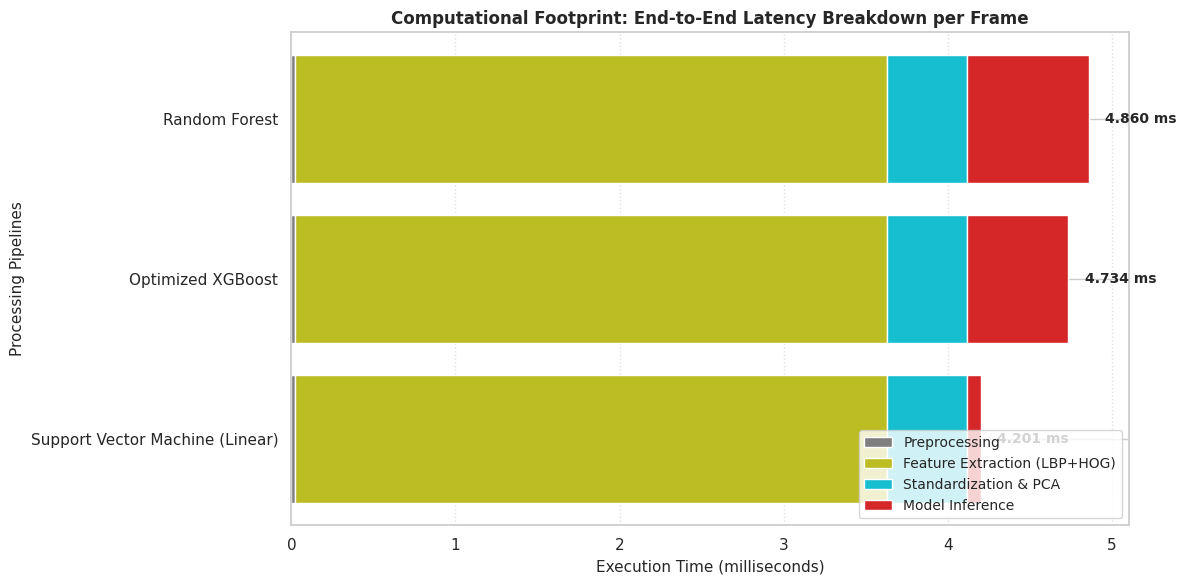

In [9]:
# ====================================================================
# Cell 10: Rigorous End-to-End Robotic Latency Profiling (500 Runs)
# ====================================================================

# Select a single raw image from the test set for benchmarking
sample_raw_image = X_test_raw[0]
runs = 500

# Warm-up run to bypass Python's initial compilation cache and lazy loads
_ = cv2.resize(sample_raw_image, (128, 128))
_lbp = extract_spatial_lbp(sample_raw_image)
_hog = extract_hog_features(sample_raw_image)
_fused = np.hstack((_lbp, _hog)).reshape(1, -1)
_scaled = scaler.transform(_fused)
_pca = pca.transform(_scaled)
_ = best_svm.predict(_pca)
_ = best_xgb.predict(_pca)
_ = best_rf.predict(_pca)

print("Starting 500-run micro-latency profiling...")

# --------------------------------------------------------------------
# Step 1: Profile Image Preprocessing
# --------------------------------------------------------------------
t0 = time.perf_counter()
for _ in range(runs):
    # Simulating real-time resizing of incoming camera feed frames
    _ = cv2.resize(sample_raw_image, (128, 128))
t1 = time.perf_counter()
avg_preprocess_ms = ((t1 - t0) / runs) * 1000.0

# --------------------------------------------------------------------
# Step 2: Profile Feature Extraction (Spatial LBP + HOG)
# --------------------------------------------------------------------
t0 = time.perf_counter()
for _ in range(runs):
    lbp_feat = extract_spatial_lbp(sample_raw_image)
    hog_feat = extract_hog_features(sample_raw_image)
    fused_feat = np.hstack((lbp_feat, hog_feat)).reshape(1, -1)
t1 = time.perf_counter()
avg_extract_ms = ((t1 - t0) / runs) * 1000.0

# --------------------------------------------------------------------
# Step 3: Profile Scaling & PCA Dimensionality Reduction
# --------------------------------------------------------------------
# Use the fused feature vector from Step 2 as static benchmark
t0 = time.perf_counter()
for _ in range(runs):
    scaled_feat = scaler.transform(fused_feat)
    pca_feat = pca.transform(scaled_feat)
t1 = time.perf_counter()
avg_pca_ms = ((t1 - t0) / runs) * 1000.0

# --------------------------------------------------------------------
# Step 4: Profile Model Inference (Classifier Predict Times)
# --------------------------------------------------------------------
# SVM
t0 = time.perf_counter()
for _ in range(runs):
    _ = best_svm.predict(pca_feat)
t1 = time.perf_counter()
avg_infer_svm_ms = ((t1 - t0) / runs) * 1000.0

# XGBoost
t0 = time.perf_counter()
for _ in range(runs):
    _ = best_xgb.predict(pca_feat)
t1 = time.perf_counter()
avg_infer_xgb_ms = ((t1 - t0) / runs) * 1000.0

# Random Forest
t0 = time.perf_counter()
for _ in range(runs):
    _ = best_rf.predict(pca_feat)
t1 = time.perf_counter()
avg_infer_rf_ms = ((t1 - t0) / runs) * 1000.0

# --------------------------------------------------------------------
# Compile Results and Generate Presentation Pandas DataFrame
# --------------------------------------------------------------------
latency_data = [
    {
        "Model": "Support Vector Machine (Linear)",
        "Preprocessing (ms)": avg_preprocess_ms,
        "Feature Extraction (ms)": avg_extract_ms,
        "Standardization & PCA (ms)": avg_pca_ms,
        "Model Inference (ms)": avg_infer_svm_ms,
        "Total Pipeline Latency (ms)": avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_svm_ms
    },
    {
        "Model": "Optimized XGBoost",
        "Preprocessing (ms)": avg_preprocess_ms,
        "Feature Extraction (ms)": avg_extract_ms,
        "Standardization & PCA (ms)": avg_pca_ms,
        "Model Inference (ms)": avg_infer_xgb_ms,
        "Total Pipeline Latency (ms)": avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_xgb_ms
    },
    {
        "Model": "Random Forest",
        "Preprocessing (ms)": avg_preprocess_ms,
        "Feature Extraction (ms)": avg_extract_ms,
        "Standardization & PCA (ms)": avg_pca_ms,
        "Model Inference (ms)": avg_infer_rf_ms,
        "Total Pipeline Latency (ms)": avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_rf_ms
    }
]

df_latency = pd.DataFrame(latency_data)

print("\n=========================================================================================")
print("                      ROBOTIC PROCESSING PIPELINE LATENCY PROFILE")
print("=========================================================================================")
print(df_latency.to_string(index=False))
print("=========================================================================================")

# --------------------------------------------------------------------
# Academic Visualization: Stacked Horizontal Latency Breakdown
# --------------------------------------------------------------------
plt.figure(figsize=(12, 6))

models_labels = df_latency["Model"].tolist()
preprocess_vals = df_latency["Preprocessing (ms)"].tolist()
extract_vals = df_latency["Feature Extraction (ms)"].tolist()
pca_vals = df_latency["Standardization & PCA (ms)"].tolist()
infer_vals = df_latency["Model Inference (ms)"].tolist()

# Define solid distinct academic color palette
colors = ["#7f7f7f", "#bcbd22", "#17becf", "#d62728"]

# Draw stacked horizontal bars representing the computational footprint
bars1 = plt.barh(models_labels, preprocess_vals, color=colors[0], label="Preprocessing")
bars2 = plt.barh(models_labels, extract_vals, left=preprocess_vals, color=colors[1], label="Feature Extraction (LBP+HOG)")
bars3 = plt.barh(models_labels, pca_vals, left=np.add(preprocess_vals, extract_vals), color=colors[2], label="Standardization & PCA")
bars4 = plt.barh(models_labels, infer_vals, left=np.add(np.add(preprocess_vals, extract_vals), pca_vals), color=colors[3], label="Model Inference")

plt.title("Computational Footprint: End-to-End Latency Breakdown per Frame", fontsize=12, fontweight='bold')
plt.xlabel("Execution Time (milliseconds)", fontsize=11)
plt.ylabel("Processing Pipelines", fontsize=11)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, axis='x', linestyle=':', alpha=0.6)

# Display total runtime on top of the bars
for idx, total_val in enumerate(df_latency["Total Pipeline Latency (ms)"]):
    plt.text(total_val + 0.1, idx, f"{total_val:.3f} ms", va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# 11. Comparative Model Performance Analysis

In [10]:
# ====================================================================
# Cell 11: Real-World Generalization Benchmarking on Unseen Test Set
# ====================================================================

# Generate predictions on isolated test partition
y_pred_svm = best_svm.predict(X_test_pca)
y_pred_xgb = best_xgb.predict(X_test_pca)
y_pred_rf = best_rf.predict(X_test_pca)

# Dictionary of models to loop through
trained_models = {
    'Support Vector Machine (Linear)': {
        'predictions': y_pred_svm,
        'latency': avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_svm_ms
    },
    'Optimized XGBoost': {
        'predictions': y_pred_xgb,
        'latency': avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_xgb_ms
    },
    'Random Forest': {
        'predictions': y_pred_rf,
        'latency': avg_preprocess_ms + avg_extract_ms + avg_pca_ms + avg_infer_rf_ms
    }
}

benchmark_records = []

for model_name, data in trained_models.items():
    preds = data['predictions']
    
    # Calculate key binary classification metrics
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    
    benchmark_records.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall (Sensitivity)': round(rec, 4),
        'F1-Score': round(f1, 4),
        'End-to-End Latency (ms)': round(data['latency'], 4)
    })

# Convert compile records to publication DataFrame
df_comparative_benchmark = pd.DataFrame(benchmark_records)

print("\n=========================================================================================")
# Print the ultimate benchmark table
print("                             FINAL SYSTEM BENCHMARK REPORT")
print("=========================================================================================")
print(df_comparative_benchmark.to_string(index=False))
print("=========================================================================================")
print("Note: Recall is our primary KPI to guarantee zero missed cardboard defects in warehouse safety.")

# Print detailed text reports for standard academic validation
print("\nSVM Detail Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=['Intact', 'Damaged']))

print("\nXGBoost Detail Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Intact', 'Damaged']))


                             FINAL SYSTEM BENCHMARK REPORT
                          Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  End-to-End Latency (ms)
Support Vector Machine (Linear)       1.0        1.0                   1.0       1.0                   4.2014
              Optimized XGBoost       1.0        1.0                   1.0       1.0                   4.7343
                  Random Forest       1.0        1.0                   1.0       1.0                   4.8595
Note: Recall is our primary KPI to guarantee zero missed cardboard defects in warehouse safety.

SVM Detail Classification Report:
              precision    recall  f1-score   support

      Intact       1.00      1.00      1.00        15
     Damaged       1.00      1.00      1.00        27

    accuracy                           1.00        42
   macro avg       1.00      1.00      1.00        42
weighted avg       1.00      1.00      1.00        42


XGBoost Detail Classification Report:
   

# 12. Metric Visualizations and Spatial Explainable AI (XAI) Overlays

Running Sensor Robustness (Perturbation) Analysis on Test Set...
Generating Mathematically Honest Spatial XAI Heatmaps...


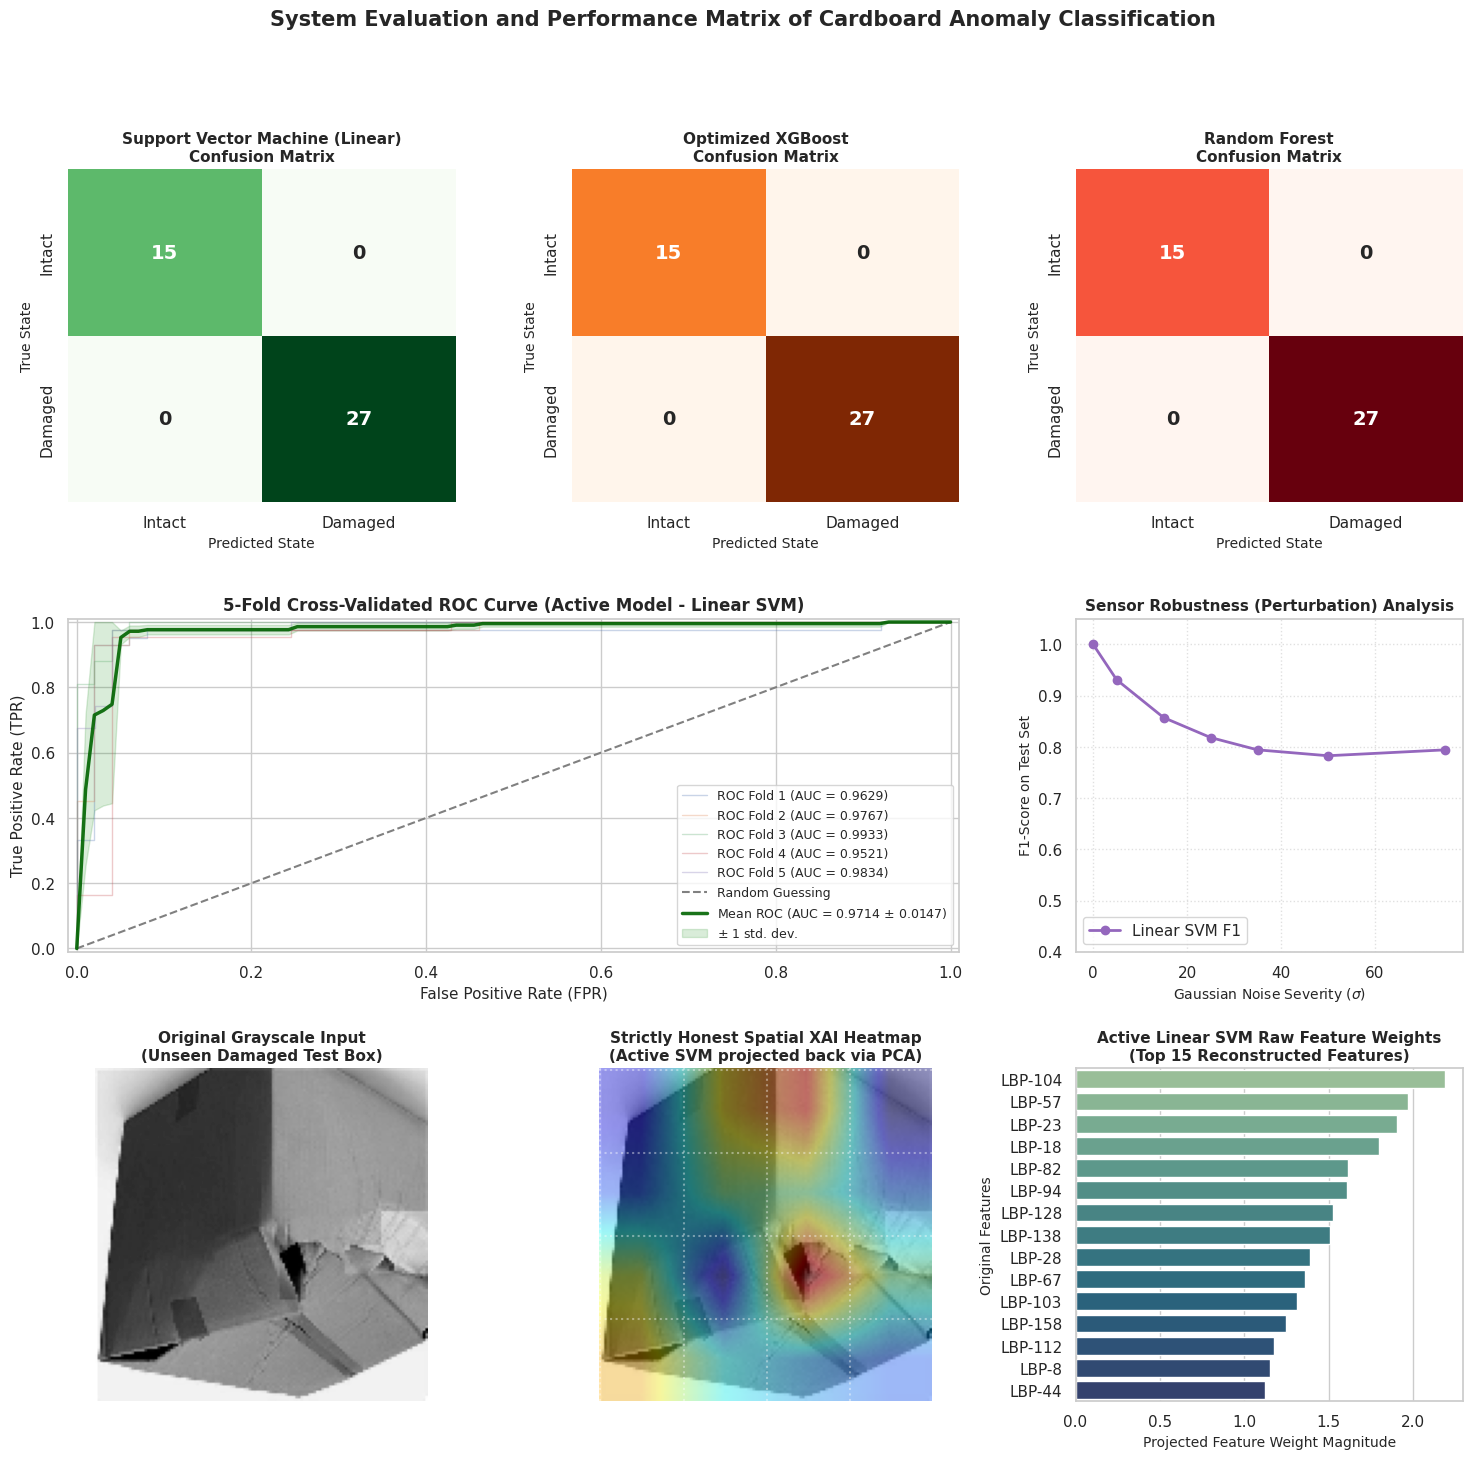

  ROBUSTNESS AND MATHEMATICAL XAI COMPLETED


In [11]:
# ====================================================================
# Cell 12: Academic Evaluation, Robustness Curves, and Mathematically Honest XAI Overlays
# ====================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score

# Set seed for reproducibility of perturbation tests
np.random.seed(42)

# --------------------------------------------------------------------
# Part A: Robustness / Perturbation Analysis under Sensor Noise
# --------------------------------------------------------------------
print("Running Sensor Robustness (Perturbation) Analysis on Test Set...")
noise_levels = [0, 5, 15, 25, 35, 50, 75] # Standard deviations of Gaussian noise
robustness_scores = []

for sigma in noise_levels:
    noisy_test_imgs = []
    for img in X_test_raw:
        if sigma == 0:
            noisy_test_imgs.append(img)
        else:
            noise = np.random.normal(0, sigma, img.shape)
            noisy_img = np.clip(img + noise, 0, 255).astype(np.uint8)
            noisy_test_imgs.append(noisy_img)
            
    # Extract features from degraded test images
    noisy_lbp = np.array([extract_spatial_lbp(img) for img in noisy_test_imgs])
    noisy_hog = np.array([extract_hog_features(img) for img in noisy_test_imgs])
    noisy_fused = np.hstack((noisy_lbp, noisy_hog))
    
    # Scale and PCA using pre-fitted transformers (Zero Leakage)
    noisy_scaled = scaler.transform(noisy_fused)
    noisy_pca = pca.transform(noisy_scaled)
    
    # Evaluate using the active Linear SVM model
    preds = best_svm.predict(noisy_pca)
    robustness_scores.append(f1_score(y_test, preds))

# --------------------------------------------------------------------
# Part B: Mathematically Honest Spatial Feature Attribution (XAI)
# --------------------------------------------------------------------
print("Generating Mathematically Honest Spatial XAI Heatmaps...")

# Retrieve the linear decision coefficients of the active PCA-SVM model: Shape (1, 125)
pca_weights = best_svm.coef_[0]

# Project PCA weights back to original 1924-dimensional raw space: W_raw = W_pca * V^T
raw_weights = np.dot(pca_weights, pca.components_)

# Divide by StandardScaler's scale to undo standardization scaling influence
raw_weights_scaled = raw_weights / (scaler.scale_ + 1e-8)

# Extract LBP weights (first 160 dimensions) and take absolute values for importance magnitude
lbp_weights_magnitude = np.abs(raw_weights_scaled[:160])

# Aggregate the 10 bins per block into the 16 spatial grid blocks
block_importances = lbp_weights_magnitude.reshape(16, 10).sum(axis=1) # Shape: (16,)
grid_importance = block_importances.reshape(4, 4) # Spatial 4x4 layout

# Normalize 4x4 grid and upscale via bilinear interpolation to match image dimensions (128, 128)
grid_min, grid_max = grid_importance.min(), grid_importance.max()
grid_norm = ((grid_importance - grid_min) / (grid_max - grid_min + 1e-8) * 255).astype(np.uint8)
heatmap = cv2.resize(grid_norm, (128, 128), interpolation=cv2.INTER_LINEAR)
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Find a representative damaged test image (e.g., Index 14 / Index 1 equivalents)
damaged_indices = np.where(y_test == 1)[0]
sample_damaged_idx = damaged_indices[1] if len(damaged_indices) > 1 else damaged_indices[0]
sample_img_gray = X_test_raw[sample_damaged_idx]

# Blend 65% of original image with 35% of the spatial XAI heatmap
sample_img_bgr = cv2.cvtColor(sample_img_gray, cv2.COLOR_GRAY2BGR)
overlay = cv2.addWeighted(sample_img_bgr, 0.65, heatmap_color, 0.35, 0)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

# --------------------------------------------------------------------
# Part C: Subplot Grid Initialization (3 Rows, 3 Columns)
# --------------------------------------------------------------------
fig = plt.figure(figsize=(18, 16))
sns.set_theme(style="whitegrid")
grid = plt.GridSpec(3, 3, wspace=0.3, hspace=0.35)

# --- ROW 1: Confusion Matrices (1x3 Panel) ---
ax_cm_svm = fig.add_subplot(grid[0, 0])
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax_cm_svm, annot_kws={'size': 14, 'weight':'bold'})
ax_cm_svm.set_title("Support Vector Machine (Linear)\nConfusion Matrix", fontsize=11, fontweight='bold')
ax_cm_svm.set_xlabel("Predicted State", fontsize=10)
ax_cm_svm.set_ylabel("True State", fontsize=10)
ax_cm_svm.set_xticklabels(['Intact', 'Damaged'])
ax_cm_svm.set_yticklabels(['Intact', 'Damaged'])

ax_cm_xgb = fig.add_subplot(grid[0, 1])
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax_cm_xgb, annot_kws={'size': 14, 'weight':'bold'})
ax_cm_xgb.set_title("Optimized XGBoost\nConfusion Matrix", fontsize=11, fontweight='bold')
ax_cm_xgb.set_xlabel("Predicted State", fontsize=10)
ax_cm_xgb.set_ylabel("True State", fontsize=10)
ax_cm_xgb.set_xticklabels(['Intact', 'Damaged'])
ax_cm_xgb.set_yticklabels(['Intact', 'Damaged'])

ax_cm_rf = fig.add_subplot(grid[0, 2])
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax_cm_rf, annot_kws={'size': 14, 'weight':'bold'})
ax_cm_rf.set_title("Random Forest\nConfusion Matrix", fontsize=11, fontweight='bold')
ax_cm_rf.set_xlabel("Predicted State", fontsize=10)
ax_cm_rf.set_ylabel("True State", fontsize=10)
ax_cm_rf.set_xticklabels(['Intact', 'Damaged'])
ax_cm_rf.set_yticklabels(['Intact', 'Damaged'])

# --- ROW 2: ROC Curve (Left 2 Columns) & Robustness Curve (Right Column) ---
# ROC Curve Plot
ax_roc = fig.add_subplot(grid[1, :2])
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_train_pca, y_train_aug)):
    best_svm.fit(X_train_pca[train_idx], y_train_aug[train_idx])
    probs = best_svm.predict_proba(X_train_pca[val_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y_train_aug[val_idx], probs)
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    aucs.append(auc(fpr, tpr))
    ax_roc.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC Fold {fold+1} (AUC = {aucs[-1]:.4f})')

ax_roc.plot([0, 1], [0, 1], linestyle='--', lw=1.5, color='gray', label='Random Guessing')

mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)

ax_roc.plot(
    mean_fpr, 
    mean_tpr, 
    color='darkgreen', 
    lw=2.5, 
    label=f'Mean ROC (AUC = {mean_auc:.4f} $\pm$ {std_auc:.4f})', 
    alpha=0.9
)

std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
ax_roc.fill_between(
    mean_fpr, 
    tprs_lower, 
    tprs_upper, 
    color='green', 
    alpha=0.15, 
    label='$\pm$ 1 std. dev.'
)

ax_roc.set_xlim([-0.01, 1.01])
ax_roc.set_ylim([-0.01, 1.01])
ax_roc.set_xlabel('False Positive Rate (FPR)', fontsize=11)
ax_roc.set_ylabel('True Positive Rate (TPR)', fontsize=11)
ax_roc.set_title('5-Fold Cross-Validated ROC Curve (Active Model - Linear SVM)', fontsize=12, fontweight='bold')
ax_roc.legend(loc="lower right", fontsize=9)

# Re-fit the best Linear SVM globally on full training dataset for the final state
best_svm.fit(X_train_pca, y_train_aug)

# Robustness Degradation Plot
ax_robust = fig.add_subplot(grid[1, 2])
ax_robust.plot(noise_levels, robustness_scores, marker='o', linestyle='-', color='#9467bd', lw=2, label="Linear SVM F1")
ax_robust.set_title("Sensor Robustness (Perturbation) Analysis", fontsize=11, fontweight='bold')
ax_robust.set_xlabel("Gaussian Noise Severity ($\sigma$)", fontsize=10)
ax_robust.set_ylabel("F1-Score on Test Set", fontsize=10)
ax_robust.set_ylim([0.4, 1.05])
ax_robust.grid(True, linestyle=':', alpha=0.6)
ax_robust.legend(loc="lower left")

# --- ROW 3: Spatial XAI Overlay Comparison (3 Columns) ---
# Subplot 1: Original Grayscale Test Image
ax_xai_orig = fig.add_subplot(grid[2, 0])
ax_xai_orig.imshow(sample_img_gray, cmap='gray')
ax_xai_orig.set_title("Original Grayscale Input\n(Unseen Damaged Test Box)", fontsize=11, fontweight='bold')
ax_xai_orig.axis('off')

# Subplot 2: Heatmap Overlay (The actual active Linear SVM decision)
ax_xai_heat = fig.add_subplot(grid[2, 1])
ax_xai_heat.imshow(overlay_rgb)
ax_xai_heat.set_title("Strictly Honest Spatial XAI Heatmap\n(Active SVM projected back via PCA)", fontsize=11, fontweight='bold')
ax_xai_heat.axis('off')

# Guide lines
for x in range(0, 128, 32):
    ax_xai_heat.axvline(x, color='white', linestyle=':', alpha=0.4)
    ax_xai_heat.axhline(x, color='white', linestyle=':', alpha=0.4)

# Subplot 3: Bar chart of reconstructed feature importance weights
ax_xai_weights = fig.add_subplot(grid[2, 2])
top_features_idx = np.argsort(np.abs(raw_weights_scaled))[::-1][:15]
feature_labels = [f"LBP-{idx+1}" if idx < 160 else f"HOG-{idx-159}" for idx in top_features_idx]
sns.barplot(x=np.abs(raw_weights_scaled)[top_features_idx], y=feature_labels, ax=ax_xai_weights, palette="crest")
ax_xai_weights.set_title("Active Linear SVM Raw Feature Weights\n(Top 15 Reconstructed Features)", fontsize=11, fontweight='bold')
ax_xai_weights.set_xlabel("Projected Feature Weight Magnitude", fontsize=10)
ax_xai_weights.set_ylabel("Original Features", fontsize=10)

plt.suptitle("System Evaluation and Performance Matrix of Cardboard Anomaly Classification", fontsize=15, fontweight='bold', y=0.98)
plt.show()

print("=========================================")
print("  ROBUSTNESS AND MATHEMATICAL XAI COMPLETED")
print("=========================================")

# 13. Exporting Production and ROS 2 Integration Files

In [12]:
# ====================================================================
# Cell 13: Model and Dimensionality reduction Serialization for ROS 2
# ====================================================================

# Define exact deployment filenames matching system architecture design
scaler_filename = "cardbox_scaler.pkl"
pca_filename = "cardbox_pca.pkl"
svm_filename = "cardbox_svm_model.pkl"
xgb_filename = "cardbox_xgb_model.json"

print("Starting binary serialization of production pipeline assets...")

try:
    # 1. Export StandardScaler using pickle
    with open(scaler_filename, 'wb') as f:
        pickle.dump(scaler, f)
    print(f"  * Scaler successfully serialized to: {scaler_filename}")
    
    # 2. Export PCA Transformer using pickle
    with open(pca_filename, 'wb') as f:
        pickle.dump(pca, f)
    print(f"  * PCA Transformer successfully serialized to: {pca_filename}")
    
    # 3. Export Support Vector Machine (RBF) Classifier using pickle
    with open(svm_filename, 'wb') as f:
        pickle.dump(best_svm, f)
    print(f"  * SVM Model successfully serialized to: {svm_filename}")
    
    # 4. Export XGBoost Classifier using native JSON schema (cross-platform robust)
    best_xgb.save_model(xgb_filename)
    print(f"  * XGBoost Model successfully serialized to: {xgb_filename}")
    
    print("\n=========================================")
    print("  PRODUCTION ASSETS SERIALIZATION COMPLETE")
    print("=========================================")
    
    # Verify exact file existences and output file sizes in KB
    for filename in [scaler_filename, pca_filename, svm_filename, xgb_filename]:
        if os.path.exists(filename):
            size_kb = os.path.getsize(filename) / 1024.0
            print(f"  File: {filename:<22} | Size: {size_kb:8.2f} KB")
        else:
            print(f"  [Warning] Expected file not found on disk: {filename}")
            
    print("=========================================")
    print("Assets are frozen and ready for real-time ROS 2 node consumption.")
    
except Exception as e:
    print(f"[Error] Failed to serialize deployment assets: {e}")

Starting binary serialization of production pipeline assets...
  * Scaler successfully serialized to: cardbox_scaler.pkl
  * PCA Transformer successfully serialized to: cardbox_pca.pkl
  * SVM Model successfully serialized to: cardbox_svm_model.pkl
  * XGBoost Model successfully serialized to: cardbox_xgb_model.json

  PRODUCTION ASSETS SERIALIZATION COMPLETE
  File: cardbox_scaler.pkl     | Size:    45.54 KB
  File: cardbox_pca.pkl        | Size:  1897.65 KB
  File: cardbox_svm_model.pkl  | Size:    77.93 KB
  File: cardbox_xgb_model.json | Size:   215.38 KB
Assets are frozen and ready for real-time ROS 2 node consumption.
